## Coding Exercise #0602

### 1. Linear regression:

In [ ]:
# Install the seaborn package to draw the scatterplot matrix. 
#!pip install --upgrade  numpy tensorflow

In [2]:
import pathlib

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

/Users/luismagh/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
2025-04-23 12:12:23.315718: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.16.2


#### 1.1. Data:

In [5]:
# Estimate the automobile fuel efficiency. 
# Using the Auto MPG data set, create the estimation model of automobile fuel efficiency in the late 1970s and the early 1980s. 
# Use tf.keras API. For more details, refer to the Keras guide. 

In [7]:
dataset_path = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

In [9]:
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight',
                'Acceleration', 'Model Year', 'Origin']
raw_dataset = pd.read_csv(dataset_path, names=column_names,
                      na_values = "?", comment='\t',
                      sep=" ", skipinitialspace=True)

dataset = raw_dataset.copy()
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


Línea a línea:
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model Year', 'Origin']
→ Se define una lista con los nombres de las columnas del dataset:

MPG: Millas por galón (eficiencia de combustible).

Cylinders: Número de cilindros del motor.

Displacement: Volumen del motor.

Horsepower: Potencia del motor.

Weight: Peso del coche.

Acceleration: Tiempo que tarda en acelerar.

Model Year: Año del modelo.

Origin: País de origen (codificado numéricamente).

raw_dataset = pd.read_csv(dataset_path, names=column_names, na_values = "?", comment='\t', sep=" ", skipinitialspace=True)
→ Carga el dataset desde la URL con pandas:

names=column_names: Usa la lista anterior como nombres de columnas.

na_values="?": Considera los símbolos "?" como datos faltantes (NaN).

comment='\t': Ignora líneas que comiencen con tabulaciones.

sep=" ": Los datos están separados por espacios.

skipinitialspace=True: Ignora espacios después de los separadores.

dataset = raw_dataset.copy()
→ Se hace una copia del dataset original para trabajar con él, sin modificar el original.

dataset.tail()
→ Muestra las últimas 5 filas del dataset para inspeccionar los datos cargados.

#### 1.2. Data Cleansing

In [11]:
# Please note that some data are missing in this dataset. 

In [12]:
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [16]:
# Missing line deleted

In [18]:
dataset = dataset.dropna()

In [20]:
# Since the "Origin" raw belongs to categorical data not numerical data, convert to one-hot encoding. 

In [22]:
origin = dataset.pop('Origin')

In [75]:
dataset['USA'] = (origin == 1)*1.0
dataset['Europe'] = (origin == 2)*1.0
dataset['Japan'] = (origin == 3)*1.0
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
393,27.0,4,140.0,86.0,2790.0,15.6,82,1.0,0.0,0.0
394,44.0,4,97.0,52.0,2130.0,24.6,82,0.0,1.0,0.0
395,32.0,4,135.0,84.0,2295.0,11.6,82,1.0,0.0,0.0
396,28.0,4,120.0,79.0,2625.0,18.6,82,1.0,0.0,0.0
397,31.0,4,119.0,82.0,2720.0,19.4,82,1.0,0.0,0.0


### **Celda 12: Conversión de la columna "Origin" a One-Hot Encoding**

```python
dataset['USA'] = (origin == 1)*1.0
dataset['Europe'] = (origin == 2)*1.0
dataset['Japan'] = (origin == 3)*1.0
dataset.tail()
```

### Línea a línea:
1. `dataset['USA'] = (origin == 1)*1.0`  
   → Crea una nueva columna llamada **'USA'**.  
   - Si el valor de `origin` es **1** (representa USA), será **True**.
   - `True * 1.0` = **1.0**, `False * 1.0` = **0.0**.
   - Resultado: columna binaria donde **1.0** indica que el coche es de **USA**.

2. `dataset['Europe'] = (origin == 2)*1.0`  
   → Similar al anterior, crea una columna **'Europe'**.  
   - **1.0** si `origin` es **2** (Europa), **0.0** en otro caso.

3. `dataset['Japan'] = (origin == 3)*1.0`  
   → Igual, crea la columna **'Japan'**.  
   - **1.0** si `origin` es **3** (Japón), **0.0** si no.

4. `dataset.tail()`  
   → Muestra las últimas 5 filas del DataFrame actualizado para ver las nuevas columnas.

---

**¿Seguimos?** 🚀

#### 1.3.Divide data into the training set and the test set.

In [27]:
train_dataset = dataset.sample(frac=0.8,random_state=0)
test_dataset = dataset.drop(train_dataset.index)

### **Celda 13: División en conjunto de entrenamiento y prueba**

```python
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)
```

### Línea a línea:
1. `train_dataset = dataset.sample(frac=0.8, random_state=0)`  
   → Selecciona una muestra aleatoria del **80%** de los datos para el **entrenamiento**.
   - `frac=0.8`: fracción del dataset a tomar.
   - `random_state=0`: asegura que la selección sea **reproducible** (misma muestra cada vez que se ejecute).

2. `test_dataset = dataset.drop(train_dataset.index)`  
   → El **20% restante** se usará para **pruebas**.
   - `drop(train_dataset.index)`: elimina las filas seleccionadas para entrenamiento, dejando el resto como prueba.

---

¿Pasamos a la siguiente? 🚀

#### 1.4.Examine the data

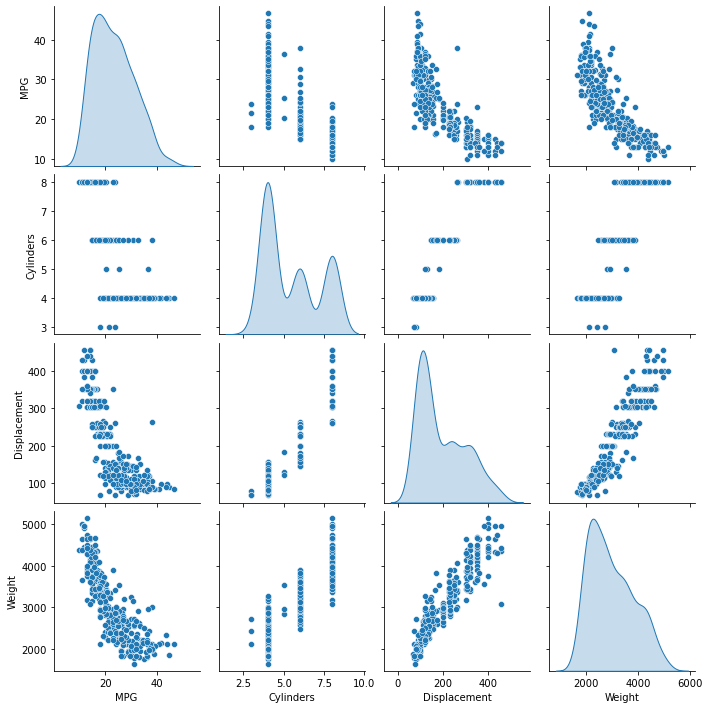

In [30]:
sns.pairplot(train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde")

#### 1.5.Check the statistics

In [32]:
train_stats = train_dataset.describe()
train_stats.pop("MPG")
train_stats = train_stats.transpose()
train_stats

,count,mean,std,min,25%,50%,75%,max
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0
USA,314.0,0.624204,0.485101,0.0,0.00,1.0,1.00,1.0
Europe,314.0,0.178344,0.383413,0.0,0.00,0.0,0.00,1.0
Japan,314.0,0.197452,0.398712,0.0,0.00,0.0,0.00,1.0


### **Celda 15: Estadísticas descriptivas del conjunto de entrenamiento**

```python
train_stats = train_dataset.describe()
train_stats.pop("MPG")
train_stats = train_stats.transpose()
train_stats
```

### Línea a línea:
1. `train_dataset.describe()`  
   → Calcula estadísticas básicas de cada columna numérica:
   - **count**, **mean**, **std**, **min**, **25%**, **50%**, **75%**, **max**.

2. `train_stats = train_dataset.describe()`  
   → Guarda esas estadísticas en la variable `train_stats`.

3. `train_stats.pop("MPG")`  
   → Elimina la columna **"MPG"** de las estadísticas, porque es la variable **objetivo**, no una predictora.

4. `train_stats = train_stats.transpose()`  
   → Transpone el DataFrame, intercambiando filas por columnas.  
   - Ahora cada **fila** representa una **variable**, y cada **columna** una medida estadística (mean, std, etc.).

5. `train_stats`  
   → Muestra las estadísticas transpuestas.

---

¿Vamos a la siguiente? 🚀

#### 1.6.Split target values, or "labels", in feature

In [34]:
train_labels = train_dataset.pop('MPG')
test_labels = test_dataset.pop('MPG')

### **Celda 16: Separación de etiquetas (variable objetivo)**

```python
train_labels = train_dataset.pop('MPG')
test_labels = test_dataset.pop('MPG')
```

### Línea a línea:
1. `train_labels = train_dataset.pop('MPG')`  
   → Extrae la columna **'MPG'** del conjunto de **entrenamiento** y la elimina de `train_dataset`.
   - `train_labels` ahora contiene solo los valores de eficiencia de combustible (objetivo a predecir).

2. `test_labels = test_dataset.pop('MPG')`  
   → Hace lo mismo con el conjunto de **prueba**.
   - `test_labels` tendrá los valores reales de **MPG** que se usarán para evaluar el modelo.

---

**Resultado:** 
- `train_dataset` y `test_dataset` contienen solo las **variables predictoras**.
- `train_labels` y `test_labels` contienen la **variable objetivo**.

---

¿Listo para seguir? 🚀

#### 1.7.Normalize data

In [36]:
def norm(x):
    return (x - train_stats['mean']) / train_stats['std']
normed_train_data = norm(train_dataset)
normed_test_data = norm(test_dataset)

### **Celda 17: Normalización de los datos**

```python
def norm(x):
    return (x - train_stats['mean']) / train_stats['std']

normed_train_data = norm(train_dataset)
normed_test_data = norm(test_dataset)
```

### Línea a línea:
1. `def norm(x):`  
   → Define una función llamada **norm** que normaliza los datos.

2. `return (x - train_stats['mean']) / train_stats['std']`  
   → Aplica la fórmula de **normalización Z-score**:
   - Resta la **media** y divide entre la **desviación estándar** de cada columna.
   - Resultado: cada columna tendrá media **0** y desviación estándar **1**.
   - Se usan los valores de **train_stats**, para asegurar coherencia entre entrenamiento y prueba.

3. `normed_train_data = norm(train_dataset)`  
   → Normaliza el conjunto de **entrenamiento** usando la función `norm`.

4. `normed_test_data = norm(test_dataset)`  
   → Normaliza el conjunto de **prueba** con la misma función.

---

**Importante:** Normalizar mejora el rendimiento del modelo y acelera el proceso de aprendizaje.

---

¿Vamos a la siguiente? 🚀

#### 1.8.Create the model

In [38]:
# Make the sequential model with densely connected layer. The output layer returns the consecutive values.  

### **Celda 18: Comentario sobre la creación del modelo**

```python
# Make the sequential model with densely connected layer. The output layer returns the consecutive values.
```

### Explicación:
- Este **comentario** describe lo que se va a hacer a continuación:
  - Se creará un **modelo secuencial** (tipo de modelo en Keras).
  - Con **capas densamente conectadas** (todas las neuronas conectadas entre capas).
  - La capa de salida entregará **valores continuos**, porque es un problema de **regresión**.

---

¿Listo para la siguiente celda con código funcional? 🚀

In [39]:
def build_model():
    model = keras.Sequential([layers.Dense(64, activation='relu', input_shape=[len(train_dataset.keys())]),
    layers.Dense(64, activation='relu'),layers.Dense(1)])
    optimizer = tf.keras.optimizers.RMSprop(0.001)
    model.compile(loss='mse',optimizer=optimizer,metrics=['mae', 'mse'])
    return model

model = build_model()

/Users/luismagh/opt/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **Celda 19: Definición y compilación del modelo de regresión**

```python
def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=[len(train_dataset.keys())]),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    optimizer = tf.keras.optimizers.RMSprop(0.001)
    model.compile(loss='mse', optimizer=optimizer, metrics=['mae', 'mse'])
    return model

model = build_model()
```

### Línea a línea:
1. `def build_model():`  
   → Define una función para construir un modelo de red neuronal.

2. `model = keras.Sequential([...])`  
   → Crea un **modelo secuencial**, donde las capas están apiladas una tras otra.

3. `layers.Dense(64, activation='relu', input_shape=[len(train_dataset.keys())])`  
   → Añade una **capa densa** (totalmente conectada) con:
   - **64 neuronas**, activación **ReLU** (Rectified Linear Unit).
   - `input_shape=[len(train_dataset.keys())]`: la forma de entrada se ajusta al número de columnas del dataset.

4. `layers.Dense(64, activation='relu')`  
   → Otra capa densa con **64 neuronas** y activación **ReLU**.

5. `layers.Dense(1)`  
   → Capa de **salida** con **1 neurona**, porque es un problema de **regresión** (predice un valor continuo).

6. `optimizer = tf.keras.optimizers.RMSprop(0.001)`  
   → Define el **optimizador** RMSprop con tasa de aprendizaje de **0.001**. RMSprop es eficiente para redes neuronales.

7. `model.compile(loss='mse', optimizer=optimizer, metrics=['mae', 'mse'])`  
   → Configura el modelo para entrenamiento:
   - **loss='mse'**: función de pérdida es el **error cuadrático medio**.
   - **metrics=['mae', 'mse']**: medirá también el **error absoluto medio** y el MSE.

8. `return model`  
   → Devuelve el modelo creado.

9. `model = build_model()`  
   → Llama a la función y guarda el modelo en la variable `model`.

---

**¿Seguimos?** 🚀

#### 1.9.Check the model

In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
# Call the model.predict method by arraying 10 samples of the train set into one batch.

### **Celda 21: Comentario sobre predicción de prueba**

```python
# Call the model.predict method by arraying 10 samples of the train set into one batch.
```

### Explicación:
- **Comentario** que indica que se va a hacer una **predicción de prueba** usando 10 muestras del conjunto de entrenamiento.
- Se utilizará el método `model.predict()` para verificar cómo responde el modelo antes de entrenarlo completamente.

---

¿Te muestro la siguiente celda de código funcional? 🚀

In [43]:
example_batch = normed_train_data[:10]
example_result = model.predict(example_batch)
example_result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[0.6337775 ],
       [0.534034  ],
       [0.33010587],
       [0.36306313],
       [0.03431547],
       [0.38090873],
       [0.08556098],
       [0.5693271 ],
       [0.4908077 ],
       [0.28734687]], dtype=float32)

### **Celda 22: Predicción con un lote de ejemplo**

```python
example_batch = normed_train_data[:10]
example_result = model.predict(example_batch)
example_result
```

### Línea a línea:
1. `example_batch = normed_train_data[:10]`  
   → Toma las **primeras 10 filas** del conjunto de entrenamiento **normalizado** para hacer una predicción de prueba.
   - `example_batch` es un lote pequeño.

2. `example_result = model.predict(example_batch)`  
   → Utiliza el modelo para predecir los valores **MPG** (eficiencia) para esas 10 muestras.

3. `example_result`  
   → Muestra en pantalla los resultados de la predicción.
   - Los valores predichos aún no serán precisos, ya que el modelo **no ha sido entrenado**.

---

¿Listo para seguir? 🚀

#### 1.10.Train the model

In [ ]:
# Put a period (.) to indicate the training process  at the end of each training epoch.  
class PrintDot(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch % 100 == 0: print('')
        print('.', end='')

EPOCHS = 1000

history = model.fit(normed_train_data, train_labels,epochs=EPOCHS, validation_split = 0.2, verbose=0,callbacks=[PrintDot()])

### **Celda 23: Entrenamiento del modelo con indicador visual**

```python
# Put a period (.) to indicate the training process at the end of each training epoch.  
class PrintDot(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch % 100 == 0: print('')
        print('.', end='')

EPOCHS = 1000

history = model.fit(normed_train_data, train_labels, epochs=EPOCHS, 
                    validation_split=0.2, verbose=0, callbacks=[PrintDot()])
```

### Línea a línea:
1. `class PrintDot(keras.callbacks.Callback):`  
   → Crea una **clase personalizada** que hereda de **keras.callbacks.Callback**.  
   - Sirve para mostrar puntos durante el entrenamiento.

2. `def on_epoch_end(self, epoch, logs):`  
   → Método que se ejecuta al finalizar cada **época**.

3. `if epoch % 100 == 0: print('')`  
   → Cada **100 épocas**, imprime un salto de línea para claridad.

4. `print('.', end='')`  
   → Imprime un **punto** (`.`) al final de cada época para indicar el progreso visualmente.

---

5. `EPOCHS = 1000`  
   → Define que el modelo se entrenará durante **1000 épocas**.

6. `history = model.fit(..., callbacks=[PrintDot()])`  
   → Entrena el modelo con:
   - `normed_train_data`, `train_labels`: datos de entrada y etiquetas.
   - `epochs=EPOCHS`: número de épocas.
   - `validation_split=0.2`: usa el **20%** del conjunto de entrenamiento como **validación**.
   - `verbose=0`: no muestra los logs normales del entrenamiento.
   - `callbacks=[PrintDot()]`: usa la clase `PrintDot` para mostrar puntos como progreso.

---

¿Listo para continuar? 🚀

In [46]:
# Visualize the performance of training process using the statistics in the history object.

In [47]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
995,2.759961,1.063264,2.759961,10.643813,2.448116,10.643813,995
996,2.927038,1.118684,2.927038,11.345405,2.463871,11.345405,996
997,2.839212,1.098778,2.839212,11.141045,2.489017,11.141045,997
998,2.828072,1.066662,2.828072,11.173993,2.496958,11.173993,998
999,2.877657,1.051546,2.877657,12.406738,2.509565,12.406738,999


### **Celda 25: Conversión de métricas de entrenamiento a DataFrame**

```python
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()
```

### Línea a línea:
1. `hist = pd.DataFrame(history.history)`  
   → Convierte el historial de entrenamiento en un **DataFrame** de pandas.
   - `history.history` es un diccionario donde:
     - Las claves son métricas: **'loss'**, **'mae'**, **'mse'**, **'val_loss'**, etc.
     - Los valores son listas con la métrica por **época**.

2. `hist['epoch'] = history.epoch`  
   → Añade una columna llamada **'epoch'** al DataFrame con los números de las épocas.

3. `hist.tail()`  
   → Muestra las **últimas 5 filas** del DataFrame para ver las métricas de las últimas épocas.

---

¿Seguimos? 🚀

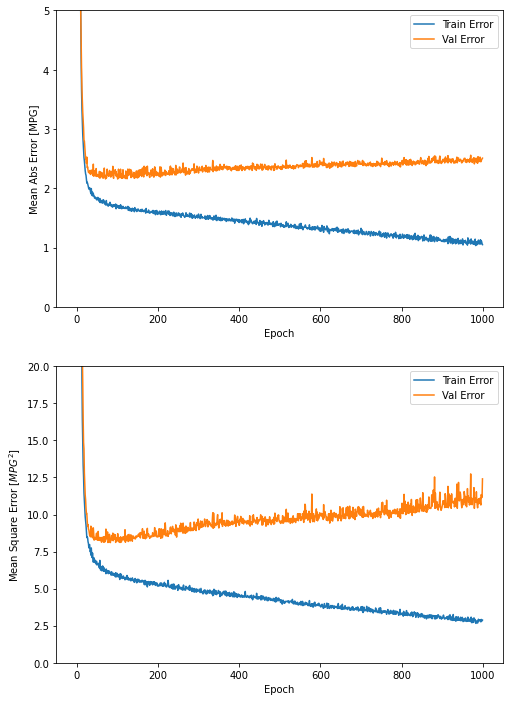

In [48]:
import matplotlib.pyplot as plt

def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch
    
    plt.figure(figsize=(8,12))
    
    plt.subplot(2,1,1)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Abs Error [MPG]')
    plt.plot(hist['epoch'], hist['mae'],label='Train Error')
    plt.plot(hist['epoch'], hist['val_mae'],label = 'Val Error')
    plt.ylim([0,5])
    plt.legend()
    
    plt.subplot(2,1,2)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error [$MPG^2$]')
    plt.plot(hist['epoch'], hist['mse'],label='Train Error')
    plt.plot(hist['epoch'], hist['val_mse'],label = 'Val Error')
    plt.ylim([0,20])
    plt.legend()
    plt.show()

plot_history(history)

### **Celda 26: Visualización gráfica del historial de entrenamiento**

```python
import matplotlib.pyplot as plt

def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch
    
    plt.figure(figsize=(8,12))
    
    plt.subplot(2,1,1)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Abs Error [MPG]')
    plt.plot(hist['epoch'], hist['mae'], label='Train Error')
    plt.plot(hist['epoch'], hist['val_mae'], label='Val Error')
    plt.ylim([0,5])
    plt.legend()
    
    plt.subplot(2,1,2)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error [$MPG^2$]')
    plt.plot(hist['epoch'], hist['mse'], label='Train Error')
    plt.plot(hist['epoch'], hist['val_mse'], label='Val Error')
    plt.ylim([0,20])
    plt.legend()
    plt.show()

plot_history(history)
```

### Línea a línea:

1. `import matplotlib.pyplot as plt`  
   → Importa la librería para graficar.

2. `def plot_history(history):`  
   → Define una función para graficar la evolución de las métricas durante el entrenamiento.

3. `hist = pd.DataFrame(history.history)`  
   → Convierte el historial a DataFrame.

4. `hist['epoch'] = history.epoch`  
   → Añade las épocas como columna.

5. `plt.figure(figsize=(8,12))`  
   → Crea una figura de tamaño 8x12.

---

#### Primer gráfico: **Error Absoluto Medio (MAE)**
6. `plt.subplot(2,1,1)`  
   → Primer gráfico (arriba).

7. `plt.xlabel('Epoch')`  
   → Etiqueta del eje X.

8. `plt.ylabel('Mean Abs Error [MPG]')`  
   → Etiqueta del eje Y.

9. `plt.plot(hist['epoch'], hist['mae'], label='Train Error')`  
   → Gráfico del **MAE** en entrenamiento.

10. `plt.plot(hist['epoch'], hist['val_mae'], label='Val Error')`  
    → Gráfico del **MAE** en validación.

11. `plt.ylim([0,5])`  
    → Limita el eje Y de 0 a 5.

12. `plt.legend()`  
    → Muestra leyenda.

---

#### Segundo gráfico: **Error Cuadrático Medio (MSE)**
13. `plt.subplot(2,1,2)`  
    → Segundo gráfico (abajo).

14. `plt.xlabel('Epoch')`  
    → Etiqueta del eje X.

15. `plt.ylabel('Mean Square Error [$MPG^2$]')`  
    → Etiqueta del eje Y.

16. `plt.plot(hist['epoch'], hist['mse'], label='Train Error')`  
    → Gráfico del **MSE** en entrenamiento.

17. `plt.plot(hist['epoch'], hist['val_mse'], label='Val Error')`  
    → Gráfico del **MSE** en validación.

18. `plt.ylim([0,20])`  
    → Limita el eje Y de 0 a 20.

19. `plt.legend()`  
    → Muestra leyenda.

20. `plt.show()`  
    → Muestra la figura completa.

---

**Resultado:** Se visualiza cómo evolucionaron los errores de entrenamiento y validación, ayudando a detectar **sobreajuste** o **subentrenamiento**.

---

¿Continuamos? 🚀

In [91]:
# By modifying the model.fit method, let trainig automatically stop when varification does not improve.  
# Use EarlyStopping callback to check the training process at every epoch.
# Automatically stop training when there is no more improvement over the specified number of epochs.  

#EXPLICACION - ### **Celda 27: Comentario sobre parada temprana**

### Explicación:
# Este **comentario** anuncia que se va a introducir la técnica de **EarlyStopping**.
# **EarlyStopping** detiene el entrenamiento automáticamente si la **validación** deja de mejorar, lo que previene el **sobreajuste** y ahorra tiempo.


/Users/luismagh/opt/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



..................................................

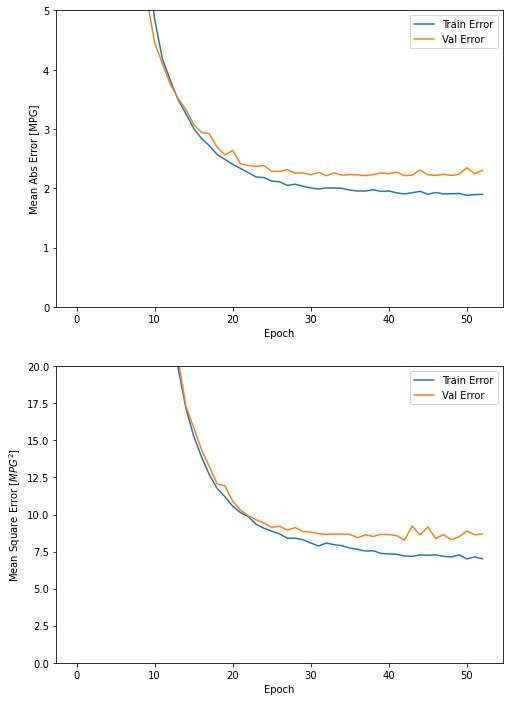

In [61]:
model = build_model()

# The 'patience' parameter is the epoch number to be used for checkking improvement. 
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(normed_train_data, train_labels, epochs=EPOCHS,
                    validation_split = 0.2, verbose=0, callbacks=[early_stop, PrintDot()])

plot_history(history)

### **Celda 28: Entrenamiento con parada temprana (EarlyStopping)**

```python
model = build_model()

# The 'patience' parameter is the epoch number to be used for checking improvement.
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(normed_train_data, train_labels, epochs=EPOCHS,
                    validation_split=0.2, verbose=0, callbacks=[early_stop, PrintDot()])

plot_history(history)
```

### Línea a línea:
1. `model = build_model()`  
   → Crea un nuevo modelo desde cero, igual que antes.

2. `early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)`  
   → Define un **callback** de parada temprana:
   - **monitor='val_loss'**: observa la métrica de **pérdida de validación**.
   - **patience=10**: si la pérdida no mejora durante **10 épocas consecutivas**, se detiene el entrenamiento.

3. `history = model.fit(..., callbacks=[early_stop, PrintDot()])`  
   → Entrena el modelo con:
   - **early_stop** para detener si no mejora.
   - **PrintDot()** para mostrar puntos como progreso.

4. `plot_history(history)`  
   → Muestra gráficamente cómo fue el entrenamiento, igual que antes.

---

**Beneficio:** Evita **sobreentrenar** el modelo si la validación ya no mejora.

---

¿Vamos con la siguiente? 🚀

#### 1.11.Check the performance of model training set.

In [64]:
loss, mae, mse = model.evaluate(normed_test_data, test_labels, verbose=2)

print("Mean absolute error of test set: {:5.2f} MPG".format(mae))

3/3 - 0s - 17ms/step - loss: 5.5004 - mae: 1.7611 - mse: 5.5004
Mean absolute error of test set:  1.76 MPG


### **Celda 29: Evaluación del modelo en el conjunto de prueba**

```python
loss, mae, mse = model.evaluate(normed_test_data, test_labels, verbose=2)

print("Mean absolute error of test set: {:5.2f} MPG".format(mae))
```

### Línea a línea:
1. `loss, mae, mse = model.evaluate(normed_test_data, test_labels, verbose=2)`  
   → Evalúa el modelo con datos que **nunca vio** (conjunto de prueba).
   - **loss**: valor de la función de pérdida (MSE).
   - **mae**: error absoluto medio (**Mean Absolute Error**) en el conjunto de prueba.
   - **mse**: error cuadrático medio (**Mean Squared Error**).

2. `verbose=2`  
   → Muestra el progreso de evaluación con más detalle.

---

3. `print("Mean absolute error of test set: {:5.2f} MPG".format(mae))`  
   → Imprime el **error absoluto medio** de la prueba formateado con **2 decimales**.
   - Indica cuánto se desvía en promedio la predicción del valor real en términos de **MPG**.

---

¿Listo para la siguiente? 🚀

#### 1.12. Prediction

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


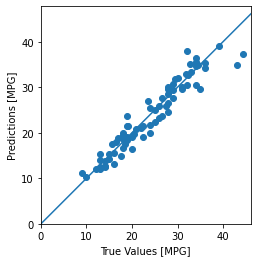

In [67]:
test_predictions = model.predict(normed_test_data).flatten()

plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100])

### **Celda 30: Visualización de las predicciones vs valores reales**

```python
test_predictions = model.predict(normed_test_data).flatten()

plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100])
```

### Línea a línea:

1. `test_predictions = model.predict(normed_test_data).flatten()`  
   → Predice los valores **MPG** para el conjunto de prueba.
   - `flatten()` convierte el array 2D a 1D para facilitar el gráfico.

2. `plt.scatter(test_labels, test_predictions)`  
   → Dibuja un **gráfico de dispersión**:
   - Eje X: **valores reales**.
   - Eje Y: **valores predichos**.
   - Si todo fuera perfecto, los puntos estarían en la línea diagonal.

---

3. `plt.xlabel('True Values [MPG]')`  
   → Etiqueta del eje X.

4. `plt.ylabel('Predictions [MPG]')`  
   → Etiqueta del eje Y.

5. `plt.axis('equal')`  
   → Escala igual para ambos ejes.

6. `plt.axis('square')`  
   → Hace el gráfico cuadrado.

7. `plt.xlim([0, plt.xlim()[1]])`  
   → Ajusta el límite inferior del eje X a **0**.

8. `plt.ylim([0, plt.ylim()[1]])`  
   → Ajusta el límite inferior del eje Y a **0**.

9. `_ = plt.plot([-100, 100], [-100, 100])`  
   → Dibuja la **línea diagonal** (línea de referencia perfecta).

---

**Resultado:** Puedes comparar qué tan cerca están las predicciones de los valores reales.

---

¿Vamos con la última celda? 🚀